✅ SHAP analysis ready
📁 Output path: ..\..\..\visualizations\plots
📊 Loading model and data...
✅ Loaded model: Pipeline
✅ Test data: 818 samples, 44 features
📊 Extracted model: CatBoostRegressor

🔍 Creating SHAP explainer...
✅ Using TreeExplainer for CatBoost
✅ SHAP values calculated: (100, 44)

📊 Creating SHAP summary plot...


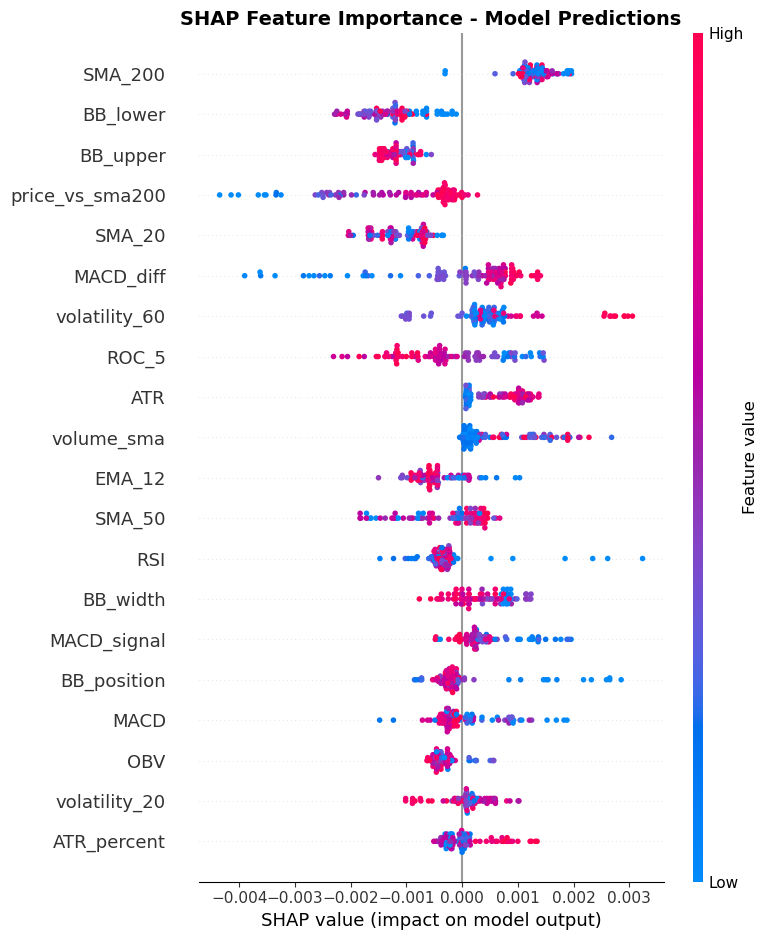

✅ Saved: ..\..\..\visualizations\plots\shap_summary.png


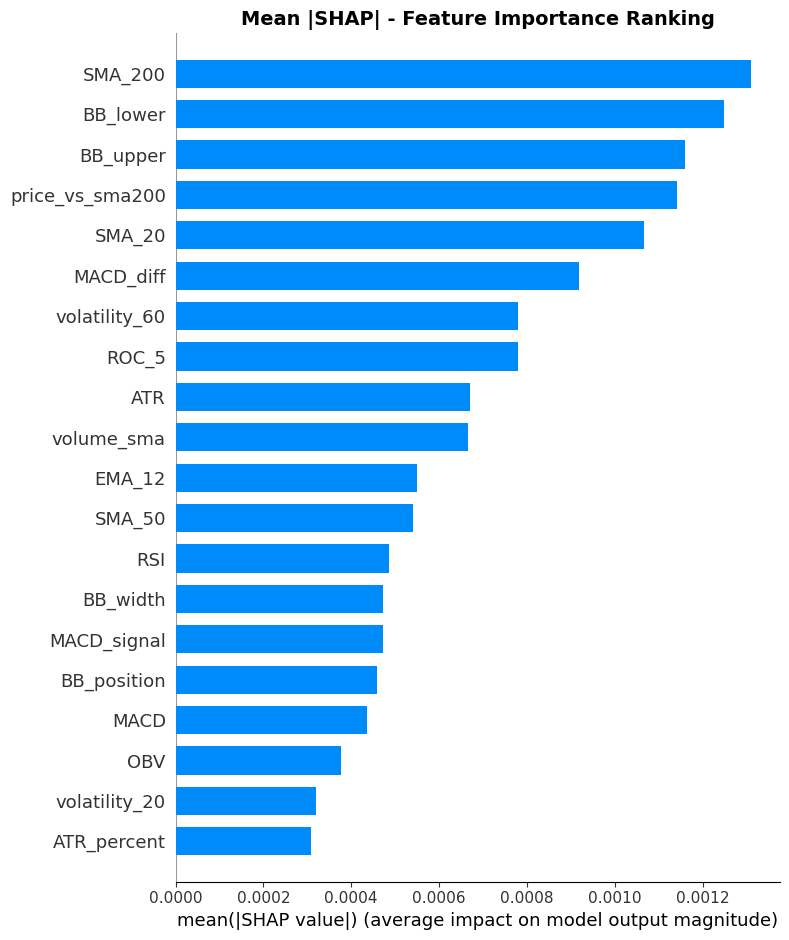

✅ Saved: ..\..\..\visualizations\plots\shap_bar.png


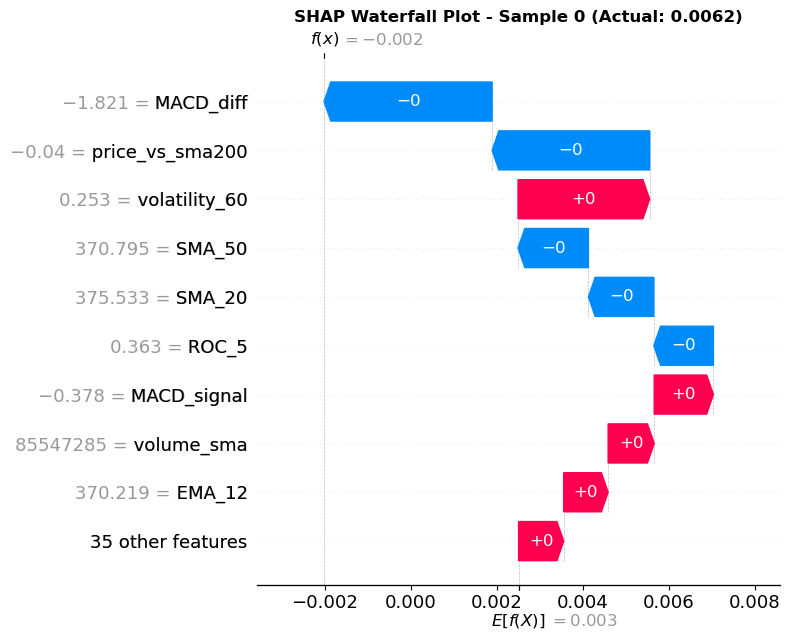

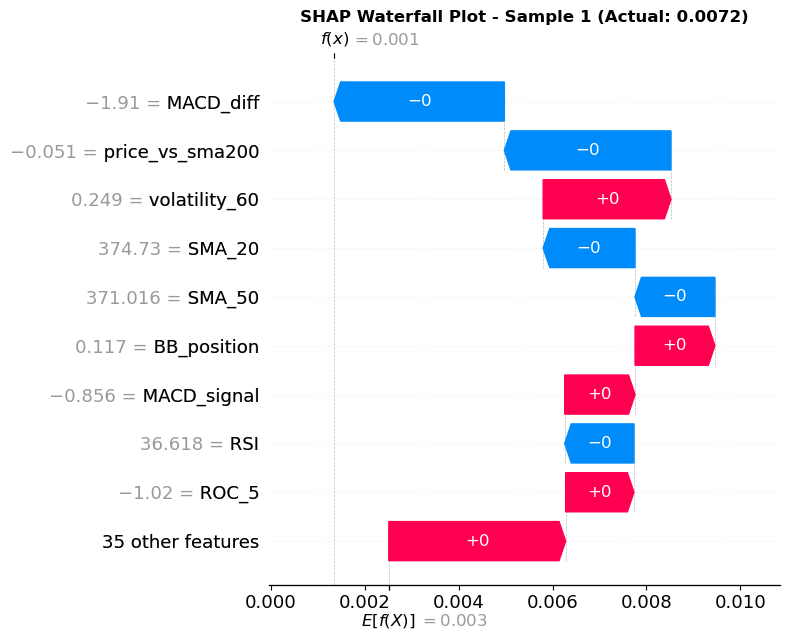

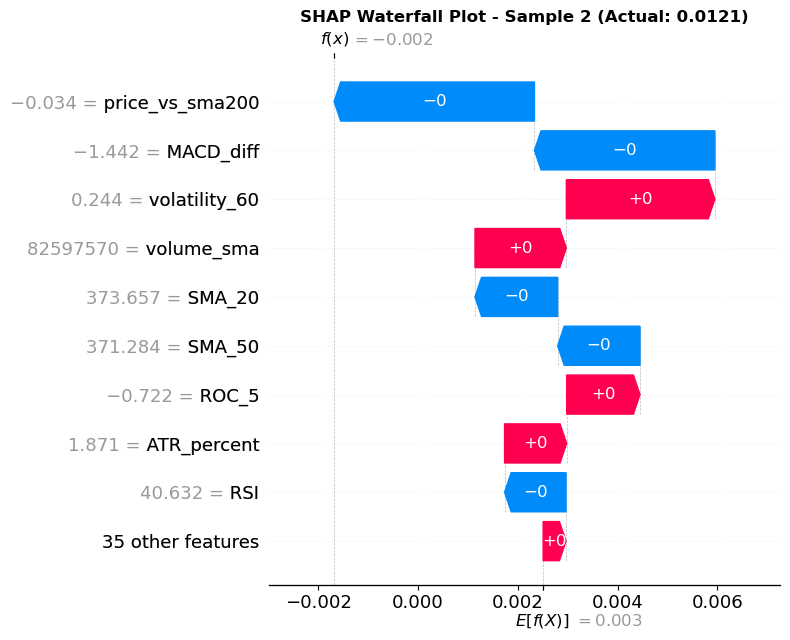


📊 Creating feature dependence plots...


<Figure size 1000x600 with 0 Axes>

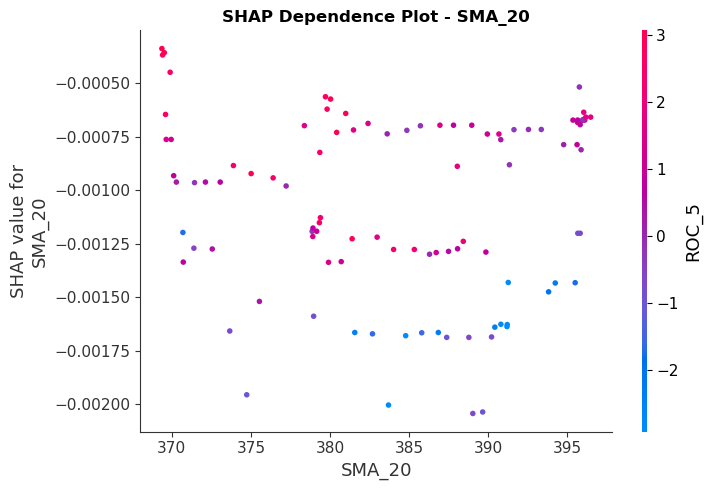

<Figure size 1000x600 with 0 Axes>

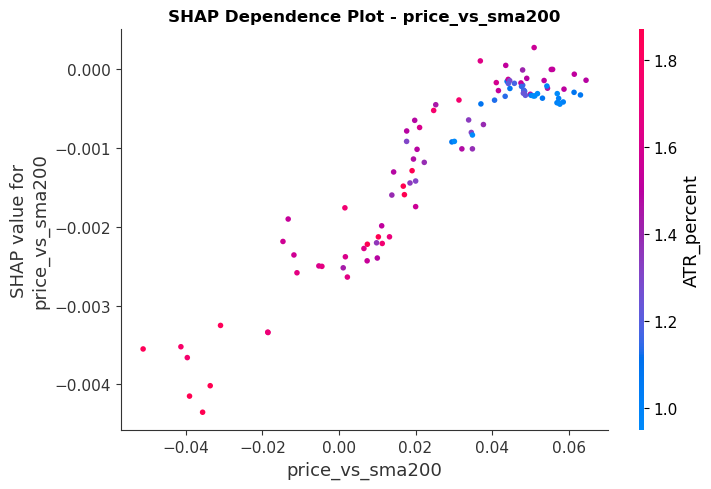

<Figure size 1000x600 with 0 Axes>

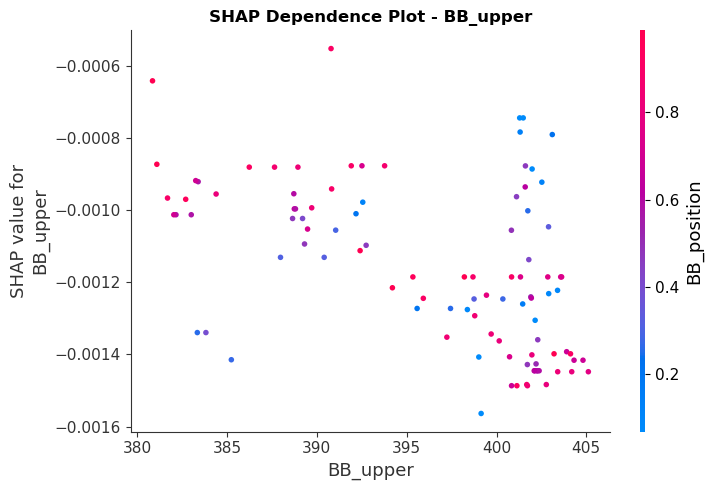

<Figure size 1000x600 with 0 Axes>

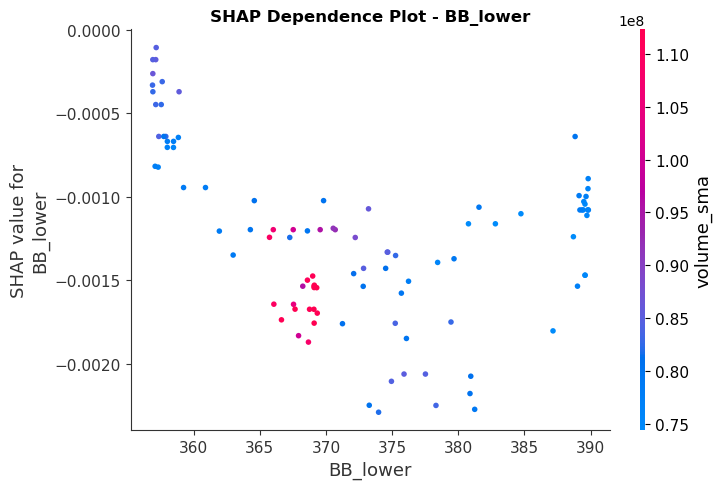

<Figure size 1000x600 with 0 Axes>

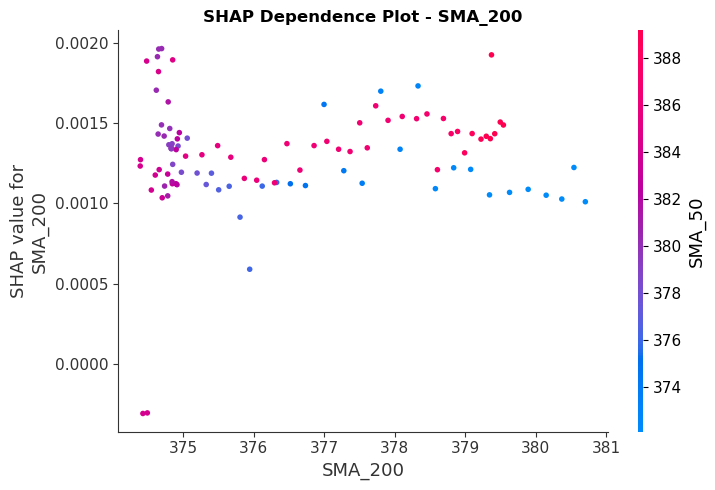

✅ All SHAP plots saved to ..\..\..\visualizations\plots


In [1]:
# Cell 1: SHAP Analysis Setup
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# SHAP
import shap

# Load paths
PROJECT_ROOT = Path('../../../')
MODELS_PATH = PROJECT_ROOT / 'models/ensembles'
DATA_PATH = PROJECT_ROOT / 'data/features/final_features.parquet'
SHAP_PATH = PROJECT_ROOT / 'visualizations/plots'
SHAP_PATH.mkdir(parents=True, exist_ok=True)

print("✅ SHAP analysis ready")
print(f"📁 Output path: {SHAP_PATH}")

# Cell 2: Load Model and Data
def load_model_and_data():
    """Load final model and test data"""
    print("📊 Loading model and data...")
    
    # Load final model
    with open(MODELS_PATH / 'final_model.pkl', 'rb') as f:
        model = pickle.load(f)
    
    # Load features
    df = pd.read_parquet(DATA_PATH)
    feature_cols = [col for col in df.columns if col != 'target_next_week']
    X = df[feature_cols].values
    y = df['target_next_week'].values
    feature_names = feature_cols
    
    # Use test set (last 20%)
    split_idx = int(len(X) * 0.8)
    X_test = X[split_idx:]
    y_test = y[split_idx:]
    
    print(f"✅ Loaded model: {type(model).__name__}")
    print(f"✅ Test data: {X_test.shape[0]} samples, {X_test.shape[1]} features")
    
    return model, X_test, y_test, feature_names

model, X_test, y_test, feature_names = load_model_and_data()

# Cell 3: Extract Regressor from Pipeline
def extract_regressor(pipeline):
    """Extract the actual model from pipeline"""
    if hasattr(pipeline, 'named_steps'):
        # Get the last step (the actual model)
        last_step = list(pipeline.named_steps.keys())[-1]
        return pipeline.named_steps[last_step]
    return pipeline

# Extract the actual model
base_model = extract_regressor(model)
print(f"📊 Extracted model: {type(base_model).__name__}")

# Cell 4: Create SHAP Explainer
print("\n🔍 Creating SHAP explainer...")

# Use TreeExplainer for tree-based models (CatBoost, XGBoost, etc.)
if 'catboost' in str(type(base_model)).lower():
    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(X_test[:100])  # Use subset for speed
    print("✅ Using TreeExplainer for CatBoost")
elif 'xgb' in str(type(base_model)).lower():
    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(X_test[:100])
    print("✅ Using TreeExplainer for XGBoost")
else:
    # For other models, use KernelExplainer (slower but universal)
    background = shap.kmeans(X_test, 50)
    explainer = shap.KernelExplainer(base_model.predict, background)
    shap_values = explainer.shap_values(X_test[:100])
    print("✅ Using KernelExplainer")

print(f"✅ SHAP values calculated: {shap_values.shape}")

# Cell 5: SHAP Summary Plot
print("\n📊 Creating SHAP summary plot...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance - Model Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SHAP_PATH / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SHAP_PATH / 'shap_summary.png'}")

# Cell 6: SHAP Bar Plot (Mean Absolute SHAP)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.title('Mean |SHAP| - Feature Importance Ranking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SHAP_PATH / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SHAP_PATH / 'shap_bar.png'}")

# Cell 7: Top Features Waterfall Plot
def plot_waterfall_for_sample(sample_idx=0):
    """Create waterfall plot for a single prediction"""
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value if hasattr(explainer, 'expected_value') else 0,
            data=X_test[sample_idx],
            feature_names=feature_names
        ),
        show=False,
        max_display=10
    )
    plt.title(f'SHAP Waterfall Plot - Sample {sample_idx} (Actual: {y_test[sample_idx]:.4f})', 
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(SHAP_PATH / f'shap_waterfall_sample_{sample_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot waterfall for first 3 samples
for i in range(3):
    plot_waterfall_for_sample(i)

# Cell 8: Feature Dependence Plots
print("\n📊 Creating feature dependence plots...")

# Get top 5 features by importance
mean_shap = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(mean_shap)[-5:]

for idx in top_features_idx:
    feature_name = feature_names[idx]
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(idx, shap_values, X_test[:100], feature_names=feature_names, 
                         show=False)
    plt.title(f'SHAP Dependence Plot - {feature_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(SHAP_PATH / f'shap_dependence_{feature_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"✅ All SHAP plots saved to {SHAP_PATH}")